# nb-svanstrom — Svanström visible drone+bird → YOLO

Per-source cleaning notebook for the Smart Spotter unified person+drone dataset.

**Output:** `svanstrom_yolo/{images,labels}/{train,val}` + `data.yaml` (nc:2, person=0 / drone=1; this source emits drone=1 boxes and empty negatives only).

**Source:** `giladfaibish/svanstrom-visible-raw` — visible (640×512) drone + bird videos, MATLAB `groundTruth` `.mat` labels decoded via `mcos-decoder`.

Run order: cells top-to-bottom on Kaggle (T4×2). Code cells numbered excluding markdown.

In [2]:
# Cell 1 — Dependencies
# mcos-decoder: reads MATLAB Computer Vision Toolbox groundTruth MCOS objects
#   (scipy/pymatreader/mat73 cannot decode these).
# imagehash + Pillow: perceptual dedupe. groundingdino via ultralytics-free path
#   is heavy; person auto-labelling is incidental here, so GroundingDINO is loaded
#   lazily only if any candidate person frames survive (most Svanström frames are
#   sky-only and contain no people).
!pip install -q mcos-decoder imagehash opencv-python-headless openpyxl
print("deps installed")

deps installed


In [3]:
# Cell 2 — Imports, constants, and tunables
import os, re, json, math, shutil, subprocess, hashlib
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
from PIL import Image
import imagehash
import openpyxl

# ---- Source geometry ----
NATIVE_W, NATIVE_H = 640, 512          # visible video resolution
DET_INPUT = 960                        # detector input scale (height-floor reference)

# ---- Class scheme (global, fixed across the whole pipeline) ----
CLASS_PERSON = 0
CLASS_DRONE  = 1
NC = 2
CLASS_NAMES = ["person", "drone"]

# ---- Drone height floor ----
# Floor defined at detector input scale (960). Sky-backed, high-contrast drones
# resolve at a lower pixel count than the 40px person floor; floor set at 18px@960.
# Native equivalent: 18 * (NATIVE_H / DET_INPUT) = 18 * 512/960 = 9.6px -> >=10px.
DRONE_FLOOR_PX_AT_960 = 18
DRONE_FLOOR_PX_NATIVE = DRONE_FLOOR_PX_AT_960 * (NATIVE_H / DET_INPUT)   # ~9.6
DRONE_FLOOR_PX_NATIVE = math.floor(DRONE_FLOOR_PX_NATIVE)                # 9 -> use >=10 via >
# Audit band upper bound: the height a 40px@960 floor would have culled to.
AUDIT_BAND_HI_NATIVE = 40 * (NATIVE_H / DET_INPUT)                       # ~21.3

# ---- Frame sampling (clips are 30fps, 10s = 300 frames) ----
SRC_FPS = 30
DRONE_CLOSE_EVERY  = 5    # 6 fps  -> close range contributes the most frames
DRONE_MEDIUM_EVERY = 9    # ~3.3 fps -> sparser, fewer frames from medium
BIRD_EVERY         = 15   # 2 fps

# ---- Bird hard-negative cap ----
BIRD_TOTAL_CAP = 2500

# ---- Dedupe ----
PHASH_HAMMING_DROP = 4    # per-video; drop a frame whose phash <=4 from a kept one

# ---- Distance bins to drop wholesale ----
DROP_BINS = {"DISTANT"}

# ---- Split ratio (whole source-groups assigned to a split) ----
VAL_FRAC = 0.15

# ---- Output ----
OUT_ROOT = Path("/kaggle/working/svanstrom_yolo")
SEED = 1337
np.random.seed(SEED)

print("constants set | drone native height floor: >", DRONE_FLOOR_PX_NATIVE,
      "px | audit band hi:", round(AUDIT_BAND_HI_NATIVE, 1), "px")

constants set | drone native height floor: > 9 px | audit band hi: 21.3 px


In [4]:
# Cell 3 — Auto-detect source paths under /kaggle/input (mount nesting unknown)
INPUT_ROOT = Path("/kaggle/input")

def _find_one(predicate, label):
    hits = [p for p in INPUT_ROOT.rglob("*") if predicate(p)]
    if not hits:
        raise FileNotFoundError(f"Could not locate {label} under {INPUT_ROOT}")
    return hits

# xlsx (single file)
xlsx_hits = _find_one(lambda p: p.is_file() and p.name.lower() == "video_dataset_description.xlsx",
                      "Video_dataset_description.xlsx")
XLSX_PATH = xlsx_hits[0]

# Video_V directory (case-insensitive); fall back to any dir holding V_*.mp4
vdir_hits = [p for p in INPUT_ROOT.rglob("*") if p.is_dir() and p.name.lower() == "video_v"]
if not vdir_hits:
    mp4s = [p for p in INPUT_ROOT.rglob("V_*.mp4")]
    if not mp4s:
        raise FileNotFoundError("No Video_V dir and no V_*.mp4 files found under /kaggle/input")
    VIDEO_DIR = mp4s[0].parent
else:
    VIDEO_DIR = vdir_hits[0]

ALL_MP4 = sorted(VIDEO_DIR.glob("V_*.mp4"))
ALL_MAT = sorted(VIDEO_DIR.glob("V_*_LABELS.mat"))

print("XLSX_PATH :", XLSX_PATH)
print("VIDEO_DIR :", VIDEO_DIR)
print("mp4 files :", len(ALL_MP4))
print("mat files :", len(ALL_MAT))
print("sample mp4:", [p.name for p in ALL_MP4[:4]])

XLSX_PATH : /kaggle/input/datasets/giladfaibish/svanstrom-visible-raw/Video_dataset_description.xlsx
VIDEO_DIR : /kaggle/input/datasets/giladfaibish/svanstrom-visible-raw/Video_V
mp4 files : 165
mat files : 165
sample mp4: ['V_BIRD_001.mp4', 'V_BIRD_002.mp4', 'V_BIRD_003.mp4', 'V_BIRD_004.mp4']


In [5]:
# Cell 4 — Parse the xlsx: distance bins keyed by (CLASS, NUMBER) for SENSOR=='V'
# Header: SENSOR | CLASS | NUMBER | "DISTANCE  BIN" (double space) | INTER BIN NUMBER
#         | DRONE TYPE / INTERNET SOURCE
wb = openpyxl.load_workbook(XLSX_PATH, read_only=True, data_only=True)
ws = wb.active
rows = list(ws.iter_rows(values_only=True))
hdr = [str(h).strip().upper() if h is not None else "" for h in rows[0]]

def col(name_contains):
    for i, h in enumerate(hdr):
        if name_contains in h:
            return i
    raise KeyError(name_contains)

c_sensor = col("SENSOR")
c_class  = col("CLASS")
c_number = col("NUMBER")
c_bin    = col("DISTANCE")   # matches "DISTANCE  BIN" regardless of spacing

# bin_lookup[(CLASS, NUMBER)] = BIN   (visible sensor only)
bin_lookup = {}
for r in rows[1:]:
    if r[c_sensor] is None:
        continue
    if str(r[c_sensor]).strip().upper() != "V":
        continue
    cls = str(r[c_class]).strip().upper()
    num = int(r[c_number])
    b   = str(r[c_bin]).strip().upper()
    bin_lookup[(cls, num)] = b

from collections import Counter as _C
print("visible rows parsed:", len(bin_lookup))
for cls in ("DRONE", "BIRD"):
    sub = {k: v for k, v in bin_lookup.items() if k[0] == cls}
    print(cls, "bins:", dict(_C(sub.values())))

visible rows parsed: 285
DRONE bins: {'CLOSE': 21, 'MEDIUM': 68, 'DISTANT': 25}
BIRD bins: {'DISTANT': 20, 'MEDIUM': 21, 'CLOSE': 10}


In [6]:
# Cell 5 — Enumerate clips, attach bin + label path, drop DISTANT
NAME_RE = re.compile(r"^V_(DRONE|BIRD)_(\d+)\.mp4$", re.IGNORECASE)

clips = []   # dict per kept clip
skipped_distant = 0
skipped_nolabel = 0
skipped_other_class = 0

for mp4 in ALL_MP4:
    m = NAME_RE.match(mp4.name)
    if not m:
        skipped_other_class += 1     # AIRPLANE/HELICOPTER not expected, guard anyway
        continue
    cls = m.group(1).upper()
    num = int(m.group(2))
    b = bin_lookup.get((cls, num))
    if b is None:
        # No xlsx entry -> cannot trust distance; skip conservatively.
        skipped_nolabel += 1
        continue
    if b in DROP_BINS:
        skipped_distant += 1
        continue
    mat = mp4.with_name(mp4.stem + "_LABELS.mat")
    clips.append({
        "mp4": mp4, "mat": mat if mat.exists() else None,
        "cls": cls, "num": num, "bin": b, "stem": mp4.stem,
    })

print("kept clips:", len(clips),
      "| DRONE:", sum(c["cls"]=="DRONE" for c in clips),
      "| BIRD:", sum(c["cls"]=="BIRD" for c in clips))
print("dropped DISTANT:", skipped_distant,
      "| no-xlsx-entry:", skipped_nolabel,
      "| non-drone/bird name:", skipped_other_class)
missing_mat = [c["stem"] for c in clips if c["cls"]=="DRONE" and c["mat"] is None]
print("DRONE clips missing .mat (will be skipped at label stage):", missing_mat)

kept clips: 120 | DRONE: 89 | BIRD: 31
dropped DISTANT: 45 | no-xlsx-entry: 0 | non-drone/bird name: 0
DRONE clips missing .mat (will be skipped at label stage): []


In [7]:
# Cell 6 — Source-recording grouping via media-created timestamp (+ filename backstop)
# Two 10s clips cut from one longer recording were exported close in time. Group by
# rounded creation_time; clips lacking a usable (non-epoch) timestamp fall back to
# filename-adjacency grouping so a stripped-timestamp subset degrades gracefully.

def probe_creation_time(mp4_path):
    """Return epoch seconds from container/stream creation_time, or None."""
    try:
        out = subprocess.run(
            ["ffprobe", "-v", "quiet", "-print_format", "json",
             "-show_entries", "format_tags:stream_tags", str(mp4_path)],
            capture_output=True, text=True, timeout=30
        ).stdout
        meta = json.loads(out) if out.strip() else {}
    except Exception:
        return None
    cands = []
    fmt_tags = (meta.get("format", {}) or {}).get("tags", {}) or {}
    for k, v in fmt_tags.items():
        if "creation" in k.lower() or "date" in k.lower():
            cands.append(v)
    for st in meta.get("streams", []) or []:
        for k, v in (st.get("tags", {}) or {}).items():
            if "creation" in k.lower() or "date" in k.lower():
                cands.append(v)
    import datetime as _dt
    for c in cands:
        c = str(c).strip().replace("Z", "+00:00")
        for fmt in ("%Y-%m-%dT%H:%M:%S.%f%z", "%Y-%m-%dT%H:%M:%S%z",
                    "%Y-%m-%dT%H:%M:%S.%f", "%Y-%m-%dT%H:%M:%S",
                    "%Y-%m-%d %H:%M:%S"):
            try:
                dt = _dt.datetime.strptime(c, fmt)
                ts = dt.timestamp()
                if ts > 86400 * 365:      # reject 1970 epoch sentinels
                    return ts
            except Exception:
                continue
    return None

TS_CLUSTER_WINDOW_S = 600   # clips within 10 min of each other -> same recording

for c in clips:
    c["ts"] = probe_creation_time(c["mp4"])

have_ts = sum(c["ts"] is not None for c in clips)
print(f"clips with usable timestamp: {have_ts}/{len(clips)}")

# Cluster within each class by timestamp proximity; filename-adjacency for the rest.
def assign_groups(clip_list):
    with_ts = sorted([c for c in clip_list if c["ts"] is not None], key=lambda c: c["ts"])
    without = sorted([c for c in clip_list if c["ts"] is None], key=lambda c: c["num"])
    gid = 0
    if with_ts:
        gid += 1
        with_ts[0]["group"] = f"{with_ts[0]['cls']}_ts{gid}"
        for prev, cur in zip(with_ts, with_ts[1:]):
            if cur["ts"] - prev["ts"] > TS_CLUSTER_WINDOW_S:
                gid += 1
            cur["group"] = f"{cur['cls']}_ts{gid}"
    # filename-adjacency: consecutive NUMBER -> same group
    fid = 0
    prev_num = None
    for c in without:
        if prev_num is None or c["num"] - prev_num > 1:
            fid += 1
        c["group"] = f"{c['cls']}_fn{fid}"
        prev_num = c["num"]

assign_groups([c for c in clips if c["cls"]=="DRONE"])
assign_groups([c for c in clips if c["cls"]=="BIRD"])

groups = Counter(c["group"] for c in clips)
print("source-recording groups:", len(groups))
print("group sizes (clips/group):", dict(Counter(groups.values())))

clips with usable timestamp: 120/120
source-recording groups: 22
group sizes (clips/group): {2: 3, 1: 6, 4: 2, 3: 3, 8: 1, 18: 1, 10: 1, 5: 1, 23: 1, 14: 1, 6: 1, 7: 1}


In [8]:
# Cell 7 — mcos-decoder wrapper: per-frame bbox list, None for absent target
# Mirrors the README usage; the for-loop maps None -> empty label (zero-byte .txt),
# pixel bbox -> YOLO normalized. No modification to load_groundtruth itself.
from mcos_decoder import load_groundtruth

def yolo_lines_for_frame(bbox, cls_idx, img_w=NATIVE_W, img_h=NATIVE_H,
                         drone_floor_native=DRONE_FLOOR_PX_NATIVE):
    """bbox = (xmin, ymin, w, h) pixels or None.
       Returns (lines, height_px). lines == [] for background or sub-floor boxes."""
    if bbox is None:
        return [], None
    x, y, w, h = [float(v) for v in bbox]
    if w <= 0 or h <= 0:
        return [], None
    # Height floor on drones only (sky-backed). Birds carry no label regardless.
    if cls_idx == CLASS_DRONE and h <= drone_floor_native:
        return [], h
    # Clip to frame, convert to YOLO normalized cx,cy,w,h.
    x2 = min(x + w, img_w); y2 = min(y + h, img_h)
    x = max(x, 0.0); y = max(y, 0.0)
    cw = x2 - x; ch = y2 - y
    if cw <= 0 or ch <= 0:
        return [], h
    cx = (x + cw / 2.0) / img_w
    cy = (y + ch / 2.0) / img_h
    nw = cw / img_w; nh = ch / img_h
    line = f"{cls_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}"
    return [line], h

# sanity probe on one drone clip with a label file
_probe = next((c for c in clips if c["cls"]=="DRONE" and c["mat"]), None)
if _probe:
    bxs = load_groundtruth(str(_probe["mat"]))
    n_present = sum(b is not None for b in bxs)
    print(f"probe {_probe['stem']}: {len(bxs)} frames, {n_present} with target")
    ex = next((b for b in bxs if b is not None), None)
    print("example bbox (xmin,ymin,w,h):", ex)

probe V_DRONE_001: 302 frames, 301 with target
example bbox (xmin,ymin,w,h): (124.92949676513672, 22.944549560546875, 75.84915924072266, 39.2028923034668)


In [10]:
# Cell 8 — Frame extraction + per-video SEQUENTIAL phash dedupe + height floor + audit
# Sky scenes drift slowly: comparing each frame against the LAST KEPT frame (not the
# whole kept history) preserves the drone's positional/scale drift while still dropping
# true frame-pause duplicates. Threshold is intentionally loose for small-target variety.
STAGE = Path("/kaggle/working/_stage")
if STAGE.exists():
    shutil.rmtree(STAGE)
(STAGE / "img").mkdir(parents=True)
(STAGE / "lbl").mkdir(parents=True)

PHASH_SEQ_DROP = 2   # vs LAST KEPT frame only; <=2 == near-identical pause, drop

audit_band = []          # drone boxes in [floor, 21px) native that relaxed floor admitted
below_floor_count = 0
records = []             # per kept frame: dict(stem, group, cls, img, lbl, has_box)

def sample_every_for(clip):
    if clip["cls"] == "BIRD":
        return BIRD_EVERY
    return DRONE_CLOSE_EVERY if clip["bin"] == "CLOSE" else DRONE_MEDIUM_EVERY

def extract_clip(clip):
    global below_floor_count
    every = sample_every_for(clip)
    is_drone = clip["cls"] == "DRONE"
    boxes = load_groundtruth(str(clip["mat"])) if (is_drone and clip["mat"]) else None

    cap = cv2.VideoCapture(str(clip["mp4"]))
    fidx = 0
    last_kept_hash = None     # sequential dedupe: compare against last kept only
    out = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        fidx += 1
        if (fidx - 1) % every != 0:
            continue
        # sequential phash dedupe (per video, vs last kept frame)
        ph = imagehash.phash(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        if last_kept_hash is not None and (ph - last_kept_hash) <= PHASH_SEQ_DROP:
            continue
        last_kept_hash = ph

        # labels
        if is_drone and boxes is not None:
            bbox = boxes[fidx - 1] if fidx - 1 < len(boxes) else None
            lines, h_px = yolo_lines_for_frame(bbox, CLASS_DRONE)
            if bbox is not None and not lines and h_px is not None and h_px <= DRONE_FLOOR_PX_NATIVE:
                below_floor_count += 1
            if h_px is not None and lines and DRONE_FLOOR_PX_NATIVE < h_px < AUDIT_BAND_HI_NATIVE:
                audit_band.append((clip["stem"], fidx, round(h_px, 1)))
        else:
            lines = []   # bird negative

        base = f"svanstrom_{clip['cls'].lower()}_{clip['num']:03d}_f{fidx:04d}"
        img_path = STAGE / "img" / f"{base}.jpg"
        lbl_path = STAGE / "lbl" / f"{base}.txt"
        cv2.imwrite(str(img_path), frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
        with open(lbl_path, "w") as f:
            f.write("\n".join(lines))   # empty file when lines == []
        out.append({"stem": base, "group": clip["group"], "cls": clip["cls"],
                    "img": img_path, "lbl": lbl_path, "has_box": bool(lines)})
    cap.release()
    return out

drone_clips = [c for c in clips if c["cls"]=="DRONE" and c["mat"]]
bird_clips  = [c for c in clips if c["cls"]=="BIRD"]

for c in drone_clips:
    records.extend(extract_clip(c))
print("drone frames staged:", len(records),
      "| with box:", sum(r["has_box"] for r in records),
      "| empty:", sum(not r["has_box"] for r in records))
print("drone boxes culled below floor:", below_floor_count)
print("drone boxes in audit band [%d,%.0f)px native: %d" %
      (DRONE_FLOOR_PX_NATIVE, AUDIT_BAND_HI_NATIVE, len(audit_band)))

bird_records = []
for c in bird_clips:
    bird_records.extend(extract_clip(c))
print("bird frames staged (pre-cap):", len(bird_records))

drone frames staged: 433 | with box: 331 | empty: 102
drone boxes culled below floor: 0
drone boxes in audit band [9,21)px native: 17
bird frames staged (pre-cap): 272


In [11]:
# Cell 9 — Bird cap: keep <=2500, drawn evenly across bird videos
bird_by_group = defaultdict(list)
for r in bird_records:
    bird_by_group[r["stem"].rsplit("_f", 1)[0]].append(r)   # per bird clip

clips_n = len(bird_by_group)
if bird_records and len(bird_records) > BIRD_TOTAL_CAP and clips_n:
    per_clip = max(1, BIRD_TOTAL_CAP // clips_n)
    kept = []
    for stem, lst in bird_by_group.items():
        lst_sorted = sorted(lst, key=lambda r: r["stem"])
        # even stride within the clip
        if len(lst_sorted) > per_clip:
            idx = np.linspace(0, len(lst_sorted) - 1, per_clip).astype(int)
            kept.extend(lst_sorted[i] for i in idx)
        else:
            kept.extend(lst_sorted)
    # if still over (rounding), trim evenly
    if len(kept) > BIRD_TOTAL_CAP:
        idx = np.linspace(0, len(kept) - 1, BIRD_TOTAL_CAP).astype(int)
        kept = [kept[i] for i in idx]
    bird_kept = kept
else:
    bird_kept = bird_records

# drop staged bird frames that didn't make the cut (free disk)
keep_set = {r["img"] for r in bird_kept}
for r in bird_records:
    if r["img"] not in keep_set:
        for p in (r["img"], r["lbl"]):
            try: p.unlink()
            except FileNotFoundError: pass

all_records = records + bird_kept
print("bird frames kept:", len(bird_kept), "| total staged records:", len(all_records))

bird frames kept: 272 | total staged records: 705


In [12]:
# Cell 10 — Optional incidental-person auto-labelling (GroundingDINO)
# Svanström visible frames are overwhelmingly sky; people appear only in occasional
# ground-level establishing shots. Run GroundingDINO ONLY on frames flagged as likely
# to contain people (here: none by construction of a sky dataset), keeping this cheap.
# Interface kept so a real candidate set can be routed through later. Persons that ARE
# detected and are truncated/edge fragments are dropped (keep drone, region ignore).
RUN_PERSON_AUTOLABEL = False   # flip True only if a candidate frame list is supplied
person_candidates = []         # populate with record stems if ground shots are found

def groundingdino_persons(image_path, box_conf=0.35, text_thresh=0.25):
    """Return list of (cx,cy,w,h) normalized person boxes. Lazy-imported."""
    raise NotImplementedError("Enable + wire GroundingDINO weights if candidates exist.")

added_person = 0
if RUN_PERSON_AUTOLABEL and person_candidates:
    for rec in all_records:
        if rec["stem"] not in person_candidates:
            continue
        try:
            boxes = groundingdino_persons(str(rec["img"]))
        except NotImplementedError:
            break
        keep = []
        for (cx, cy, w, h) in boxes:
            # drop edge/truncated fragments
            if cx - w/2 < 0.01 or cx + w/2 > 0.99 or cy - h/2 < 0.01 or cy + h/2 > 0.99:
                continue
            keep.append(f"{CLASS_PERSON} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        if keep:
            with open(rec["lbl"], "a") as f:
                prev = rec["lbl"].read_text()
                pre = "\n" if prev and not prev.endswith("\n") else ""
                f.write(pre + "\n".join(keep))
            rec["has_box"] = True
            added_person += keep.__len__()

print("incidental person boxes added:", added_person,
      "(autolabel enabled:", RUN_PERSON_AUTOLABEL, ")")

incidental person boxes added: 0 (autolabel enabled: False )


In [13]:
# Cell 11 — Split whole source-groups into train/val
groups_all = sorted({r["group"] for r in all_records})
rng = np.random.default_rng(SEED)
rng.shuffle(groups_all)

# assign groups to val until ~VAL_FRAC of frames reached
frames_per_group = Counter(r["group"] for r in all_records)
total_frames = sum(frames_per_group.values())
val_target = int(round(total_frames * VAL_FRAC))

val_groups, acc = set(), 0
for g in groups_all:
    if acc >= val_target:
        break
    val_groups.add(g); acc += frames_per_group[g]

def split_of(rec):
    return "val" if rec["group"] in val_groups else "train"

split_counts = Counter(split_of(r) for r in all_records)
print("val groups:", len(val_groups), "/", len(groups_all))
print("frame split:", dict(split_counts),
      "| val frac:", round(split_counts['val']/max(total_frames,1), 3))

val groups: 5 / 22
frame split: {'train': 589, 'val': 116} | val frac: 0.165


In [14]:
# Cell 12 — Materialize YOLO layout: images/ + labels/ per split, + data.yaml
if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)
for sub in ("images/train", "images/val", "labels/train", "labels/val"):
    (OUT_ROOT / sub).mkdir(parents=True)

for rec in all_records:
    sp = split_of(rec)
    dst_img = OUT_ROOT / "images" / sp / f"{rec['stem']}.jpg"
    dst_lbl = OUT_ROOT / "labels" / sp / f"{rec['stem']}.txt"
    shutil.copy2(rec["img"], dst_img)
    shutil.copy2(rec["lbl"], dst_lbl)

data_yaml = f"""# Svanström visible drone+bird -> YOLO (this source: drone=1 + empty negatives)
path: {OUT_ROOT}
train: images/train
val: images/val
nc: {NC}
names:
  0: {CLASS_NAMES[0]}
  1: {CLASS_NAMES[1]}
"""
(OUT_ROOT / "data.yaml").write_text(data_yaml)
print("written to", OUT_ROOT)
print(data_yaml)

written to /kaggle/working/svanstrom_yolo
# Svanström visible drone+bird -> YOLO (this source: drone=1 + empty negatives)
path: /kaggle/working/svanstrom_yolo
train: images/train
val: images/val
nc: 2
names:
  0: person
  1: drone



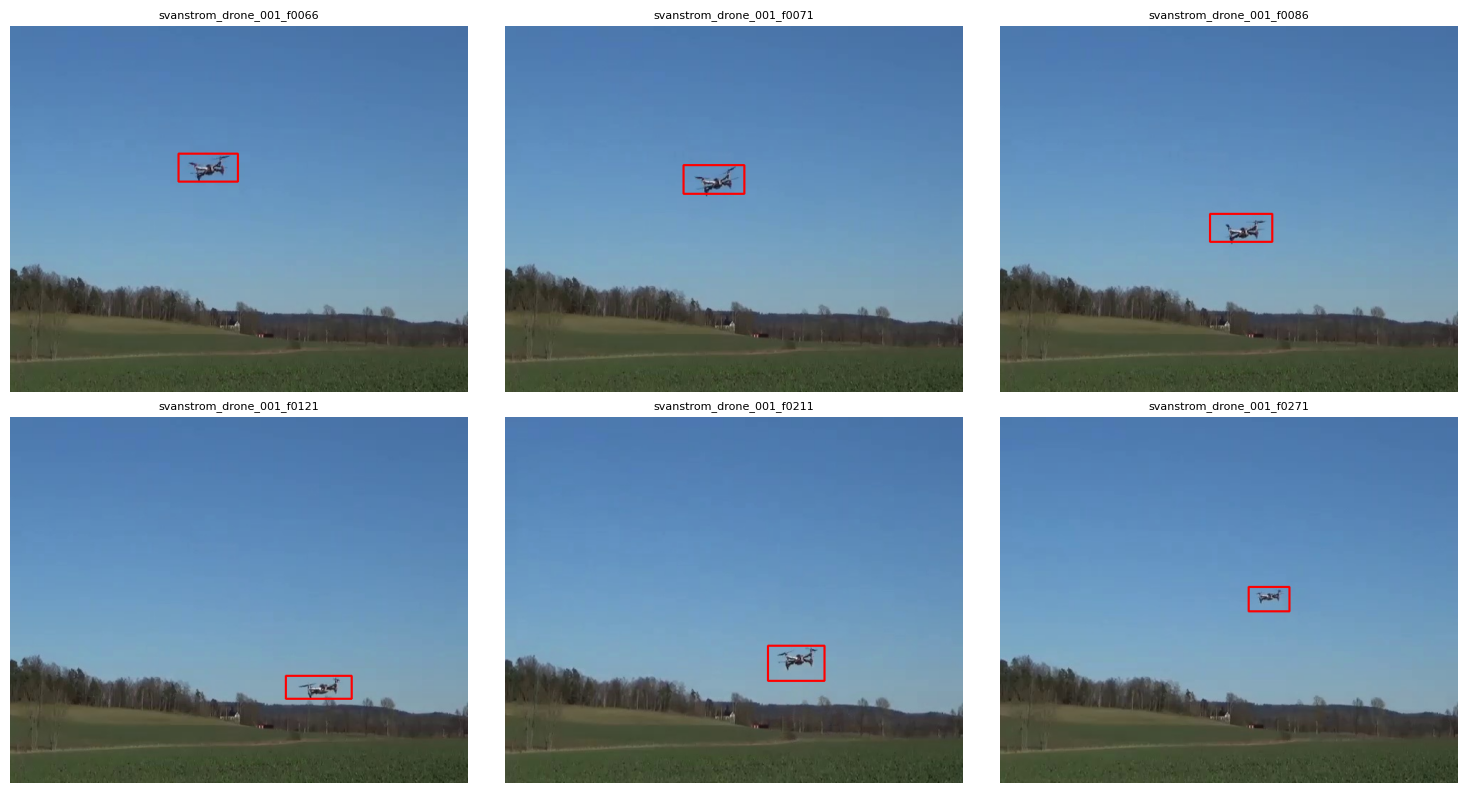

In [15]:
# Cell 13 — Draw-box visual verification (mandatory per source)
import matplotlib.pyplot as plt

def load_yolo_boxes(lbl_path, w, h):
    out = []
    if not Path(lbl_path).exists():
        return out
    for ln in Path(lbl_path).read_text().splitlines():
        if not ln.strip():
            continue
        cls, cx, cy, bw, bh = ln.split()
        cls = int(cls); cx=float(cx); cy=float(cy); bw=float(bw); bh=float(bh)
        x1 = (cx - bw/2)*w; y1 = (cy - bh/2)*h
        x2 = (cx + bw/2)*w; y2 = (cy + bh/2)*h
        out.append((cls, x1, y1, x2, y2))
    return out

# sample a few drone frames that HAVE boxes
drone_with_box = [r for r in all_records if r["cls"]=="DRONE" and r["has_box"]]
sample = drone_with_box[:6] if len(drone_with_box) >= 6 else drone_with_box
if sample:
    cols = 3; rowsN = math.ceil(len(sample)/cols)
    fig, axes = plt.subplots(rowsN, cols, figsize=(15, 4*rowsN))
    axes = np.array(axes).reshape(-1)
    for ax, rec in zip(axes, sample):
        sp = split_of(rec)
        img = cv2.cvtColor(cv2.imread(str(OUT_ROOT/"images"/sp/f"{rec['stem']}.jpg")), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        for cls, x1, y1, x2, y2 in load_yolo_boxes(OUT_ROOT/"labels"/sp/f"{rec['stem']}.txt", w, h):
            color = (255,0,0) if cls==CLASS_DRONE else (0,255,0)
            cv2.rectangle(img, (int(x1),int(y1)), (int(x2),int(y2)), color, 2)
        ax.imshow(img); ax.set_title(rec["stem"], fontsize=8); ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No drone frames with boxes to visualize.")

In [16]:
# Cell 14 — Label sanity scan + missing/empty-label manifest
n_img = n_lbl = n_empty = n_box = 0
class_counter = Counter()
bad = []
empty_manifest = []   # images with missing/empty label (unlabeled-drone audit input)

for sp in ("train", "val"):
    for img in sorted((OUT_ROOT/"images"/sp).glob("*.jpg")):
        n_img += 1
        lbl = OUT_ROOT/"labels"/sp/f"{img.stem}.txt"
        if not lbl.exists():
            empty_manifest.append({"split": sp, "image": img.name, "reason": "missing"})
            continue
        n_lbl += 1
        txt = lbl.read_text().strip()
        if not txt:
            n_empty += 1
            empty_manifest.append({"split": sp, "image": img.name, "reason": "empty"})
            continue
        for ln in txt.splitlines():
            parts = ln.split()
            if len(parts) != 5:
                bad.append((lbl.name, "ncols", ln)); continue
            c = int(parts[0]); vals = list(map(float, parts[1:]))
            if c not in (CLASS_PERSON, CLASS_DRONE):
                bad.append((lbl.name, "class", ln))
            if any(v < 0 or v > 1 for v in vals):
                bad.append((lbl.name, "range", ln))
            class_counter[c] += 1
            n_box += 1

print(f"images: {n_img} | label files: {n_lbl} | empty labels: {n_empty} | boxes: {n_box}")
print("class instance counts:", {CLASS_NAMES[k]: v for k, v in class_counter.items()})
print("malformed lines:", len(bad))
for b in bad[:10]:
    print("  ", b)

# write manifests
man_dir = OUT_ROOT
(man_dir / "missing_empty_label_manifest.json").write_text(json.dumps(empty_manifest, indent=2))
(man_dir / "drone_floor_audit.json").write_text(json.dumps(
    {"below_floor_culled": below_floor_count,
     "audit_band_native_px": [DRONE_FLOOR_PX_NATIVE, round(AUDIT_BAND_HI_NATIVE,1)],
     "audit_band_boxes": audit_band[:5000]}, indent=2))
print("manifests written:",
      (man_dir/"missing_empty_label_manifest.json").name, "|",
      (man_dir/"drone_floor_audit.json").name)
print("empty/missing-label images logged:", len(empty_manifest))

images: 705 | label files: 705 | empty labels: 374 | boxes: 331
class instance counts: {'drone': 331}
malformed lines: 0
manifests written: missing_empty_label_manifest.json | drone_floor_audit.json
empty/missing-label images logged: 374


In [17]:
# Cell 15 — Final summary (this is the notebook OUTPUT consumed by nb-unify)
print("="*60)
print("nb-svanstrom complete")
print("="*60)
print("output root:", OUT_ROOT)
print("train images:", len(list((OUT_ROOT/'images/train').glob('*.jpg'))))
print("val images  :", len(list((OUT_ROOT/'images/val').glob('*.jpg'))))
print("drone instances:", class_counter[CLASS_DRONE])
print("person instances:", class_counter[CLASS_PERSON])
print("empty negatives:", n_empty)
print("data.yaml present:", (OUT_ROOT/'data.yaml').exists())
print()
print("This output dir is passed to nb-unify via Kaggle notebook-output-as-input.")
print("nb-unify globs for data.yaml to auto-detect this source root.")

nb-svanstrom complete
output root: /kaggle/working/svanstrom_yolo
train images: 589
val images  : 116
drone instances: 331
person instances: 0
empty negatives: 374
data.yaml present: True

This output dir is passed to nb-unify via Kaggle notebook-output-as-input.
nb-unify globs for data.yaml to auto-detect this source root.
